# Chapter 08 — Where Are the Finished Projects?

**Companion to *Applied AI*.**

This notebook accompanies Chapter 8. The chapter's answer to its own title is
arithmetic rather than opinion, and the arithmetic is Amdahl's law.

## Question

If the coding part of a project gets infinitely fast, **what is the ceiling on
the whole project?**

## What this notebook establishes

- Amdahl's cap reproduced exactly from the chapter's table, including the
  1.43× at *p* = 30%.
- The second, nastier result: when acceleration **enlarges** the unaccelerated
  remainder, the ceiling falls.
- The same arithmetic applied to cost, using this book's **one measured cost
  result** — Chapter 28's execution ladder — read from the preserved evidence
  bundle rather than retyped.

## What this notebook does **not** establish

- Amdahl's law is arithmetic, not a measurement. The share *p* is **your
  estimate**, and the chapter says so.
- The DORA, METR, GitClear and AlphaEvolve results the chapter cites are **not**
  reproduced here. They are external measurements with stated bounds.
- The cost section reproduces a **single run** on one synthetic 40-item
  workload under a declared $5-per-person scenario. It is not an economic
  result and does not generalise.

## Setup

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt

def find_evidence_dir() -> Path:
    """Locate the preserved Applied AI evidence bundles.

    Override with the APPLIED_AI_EVIDENCE environment variable. When this
    notebook moves to a standalone repository, copy the bundle named under
    `LADDER` below to ./evidence/ and it will be found automatically.
    """
    env = os.environ.get("APPLIED_AI_EVIDENCE")
    if env and Path(env).expanduser().is_dir():
        return Path(env).expanduser()
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        for cand in (base / "evidence",
                     base / "experiments" / "applied-ai" / "evidence"):
            if (cand / "execution-ladder").is_dir():
                return cand
    raise FileNotFoundError(
        "Preserved evidence not found. Set APPLIED_AI_EVIDENCE to the "
        "directory holding the Applied AI evidence bundles."
    )

EVIDENCE_DIR = find_evidence_dir()
LADDER = EVIDENCE_DIR / "execution-ladder" / "2026-09-14-7a0d43b" / "analysis.json"
print("EVIDENCE_DIR:", EVIDENCE_DIR)
print("ladder analysis present:", LADDER.exists())

EVIDENCE_DIR: $APPLIED_AI_EVIDENCE
ladder analysis present: True


## 1. The cap

Amdahl: if a fraction *p* of elapsed time can be accelerated by *s*, and the
rest cannot, total speedup is

```text
speedup = 1 / ((1 - p) + p / s)
```

and as *s* goes to infinity the cap is `1 / (1 - p)`.

In [2]:
def speedup(p, s):
    return 1 / ((1 - p) + p / s)

def cap(p):
    return float("inf") if p >= 1 else 1 / (1 - p)

print(f"{'coding share p':<18}{'cap 1/(1-p)':>14}")
print("-" * 32)
for p in (0.10, 0.20, 0.30, 0.50, 0.90):
    print(f"{p:<18.0%}{cap(p):>13.2f}x")

assert abs(cap(0.30) - 1.4285714) < 1e-6
print()
print("assertion held: p = 30% gives the chapter's 1.43x")

coding share p       cap 1/(1-p)
--------------------------------
10%                        1.11x
20%                        1.25x
30%                        1.43x
50%                        2.00x
90%                       10.00x

assertion held: p = 30% gives the chapter's 1.43x


The chapter's framing: give yourself the hundred-times coworker, make them
*infinitely* fast, and a project that is 30% coding finishes a shade over forty
percent faster.

In [3]:
print(f"{'coworker speed s':<20}{'whole-project speedup at p=30%':>34}")
print("-" * 56)
for s in (2, 10, 100, 1_000, 10_000, float("inf")):
    label = "infinite" if s == float("inf") else f"{s:,}x"
    val = cap(0.30) if s == float("inf") else speedup(0.30, s)
    print(f"{label:<20}{val:>33.3f}x")

coworker speed s        whole-project speedup at p=30%
--------------------------------------------------------
2x                                              1.176x
10x                                             1.370x
100x                                            1.422x
1,000x                                          1.428x
10,000x                                         1.429x
infinite                                        1.429x


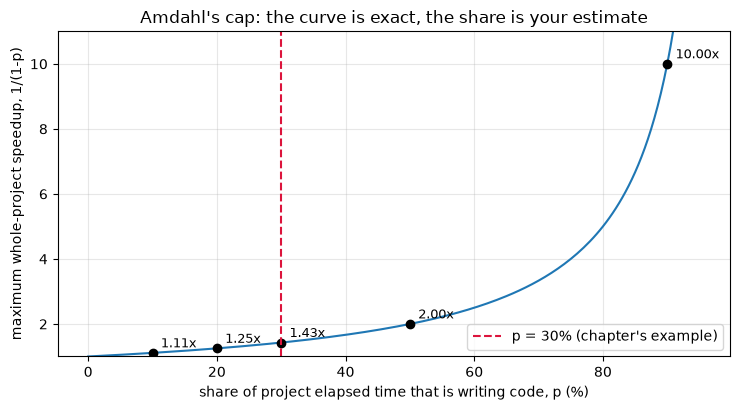

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ps = [i / 200 for i in range(0, 191)]
ax.plot([p * 100 for p in ps], [cap(p) for p in ps])
for p in (0.10, 0.20, 0.30, 0.50, 0.90):
    ax.plot(p * 100, cap(p), "o", color="black")
    ax.annotate(f"{cap(p):.2f}x", (p * 100, cap(p)),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.axvline(30, color="crimson", linestyle="--", label="p = 30% (chapter's example)")
ax.set_xlabel("share of project elapsed time that is writing code, p (%)")
ax.set_ylabel("maximum whole-project speedup, 1/(1-p)")
ax.set_title("Amdahl's cap: the curve is exact, the share is your estimate")
ax.set_ylim(1, 11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. The ceiling that falls

The chapter's harder point: accelerating generation can **grow** the part it
cannot accelerate. More code means more review, more integration surface, more
places for defects to hide.

In [5]:
print(f"{'serial remainder':<22}{'coding share':<16}{'cap':>10}")
print("-" * 50)
for remainder in (0.60, 0.70, 0.75, 0.80, 0.90):
    p = 1 - remainder
    print(f"{remainder:<22.0%}{p:<16.0%}{cap(p):>9.2f}x")

print()
print("The chapter's example: if faster generation moves the remainder from")
print(f"70% to 80%, the cap falls from {cap(0.30):.2f}x to {cap(0.20):.2f}x.")
print("The intervention lowered its own ceiling.")

serial remainder      coding share           cap
--------------------------------------------------
60%                   40%                  1.67x
70%                   30%                  1.43x
75%                   25%                  1.33x
80%                   20%                  1.25x
90%                   10%                  1.11x

The chapter's example: if faster generation moves the remainder from
70% to 80%, the cap falls from 1.43x to 1.25x.
The intervention lowered its own ceiling.


## 3. What the 70% is made of

The chapter's table. This is the thesis of Part 1 arriving from a different
direction: the bottleneck is composed almost entirely of the four jobs
Chapter 2 argued cannot leave the human.

In [6]:
REMAINDER = [
    ("Deciding what should be built, and what done means", "intent"),
    ("Agreeing this is the right thing, and permitting it", "authority"),
    ("Establishing that it actually works",                 "verification"),
    ("Knowing when the model is the wrong tool",            "frontier judgment"),
]
for work, name in REMAINDER:
    print(f"  {work:<54} -> {name}")
print()
print("We accelerated the one part of the work that was never the constraint.")

  Deciding what should be built, and what done means     -> intent
  Agreeing this is the right thing, and permitting it    -> authority
  Establishing that it actually works                    -> verification
  Knowing when the model is the wrong tool               -> frontier judgment

We accelerated the one part of the work that was never the constraint.


## 4. The same arithmetic, applied to cost — from real evidence

The chapter makes the cost version of this point using Chapter 28's measured
run. Rather than retype its numbers, read them out of the preserved bundle.

In [7]:
analysis = json.loads(LADDER.read_text(encoding="utf-8"))
SCENARIO = "5.0"          # $ per question put to a person, declared in the run

rows = {}
for arm in ("ladder", "top-first"):
    a = analysis["arms"][arm]
    at = a["by_human_cost"][SCENARIO]
    rows[arm] = {
        "model_spend": a["by_human_cost"]["0.0"]["total_cost_usd"],
        "total": at["total_cost_usd"],
        "per_accepted": at["cost_to_accepted_outcome"],
    }

print(f"scenario: ${SCENARIO} per question put to a person (declared, not a wage)")
print()
print(f"{'arm':<14}{'model spend':>14}{'total cost':>14}{'per accepted outcome':>24}")
print("-" * 68)
for arm, r in rows.items():
    print(f"{arm:<14}${r['model_spend']:>13.4f}${r['total']:>13.2f}"
          f"${r['per_accepted']:>23.3f}")

ratio_model = rows["top-first"]["model_spend"] / rows["ladder"]["model_spend"]
ratio_total = rows["top-first"]["total"] / rows["ladder"]["total"]
print()
print(f"top-first spends {ratio_model:.1f}x more on MODELS")
print(f"top-first spends {ratio_total:.2f}x more in TOTAL")

scenario: $5.0 per question put to a person (declared, not a wage)

arm              model spend    total cost    per accepted outcome
--------------------------------------------------------------------
ladder        $       0.0056$        35.01$                  1.061
top-first     $       0.0317$        45.03$                  1.453

top-first spends 5.7x more on MODELS
top-first spends 1.29x more in TOTAL


## Observation

In [8]:
d_model = rows["top-first"]["model_spend"] - rows["ladder"]["model_spend"]
d_total = rows["top-first"]["total"] - rows["ladder"]["total"]
print(f"difference in model spend : ${d_model:.4f}")
print(f"difference in total cost  : ${d_total:.2f}")
print(f"the model difference is {d_model / d_total:.2%} of the total difference")
print()
print("Making the model work six times cheaper barely moved the bill,")
print("because the model work was never most of it. That is Amdahl,")
print("in dollars instead of minutes.")

difference in model spend : $0.0261
difference in total cost  : $10.03
the model difference is 0.26% of the total difference

Making the model work six times cheaper barely moved the bill,
because the model work was never most of it. That is Amdahl,
in dollars instead of minutes.


The chapter's warning travels with this number. The ladder was cheaper per
accepted outcome **and was still not adopted**, because it accepted one wrong
answer where the control accepted none and its frozen rule forbade that. Cost is
not the only axis, and the Chapter 28 notebook reads that decision in full.

In [9]:
dec = analysis["decision"]
print("preregistered decision, read from the bundle:")
for k, v in dec["conditions"].items():
    print(f"  {k:<34} {v}")
print(f"  {'ladder_justified':<34} {dec['ladder_justified']}")
print(f"  verdict: {dec['verdict']}")

preregistered decision, read from the bundle:
  cheaper_per_accepted_outcome       True
  correct_acceptances_within_one     True
  no_more_negative_acceptances       False
  ladder_justified                   False
  verdict: top-rung-first wins on this workload


## 5. Measure arrival, not motion

The chapter's actionable section. Almost every AI productivity metric in common
use measures motion.

In [10]:
MOTION  = ["tokens generated", "suggestions accepted", "lines written",
           "pull requests opened", "commits"]
ARRIVAL = ["started vs finished per quarter", "cycle time to genuinely closed",
           "rework rate within 30 days", "backlog age (not size)"]

print("MOTION (rises without anything finishing):")
for m in MOTION:
    print("   ", m)
print()
print("ARRIVAL (what the sales pitch actually predicts):")
for a in ARRIVAL:
    print("   ", a)

MOTION (rises without anything finishing):
    tokens generated
    suggestions accepted
    lines written
    pull requests opened
    commits

ARRIVAL (what the sales pitch actually predicts):
    started vs finished per quarter
    cycle time to genuinely closed
    rework rate within 30 days
    backlog age (not size)


In [11]:
# A team can double every motion metric while finishing strictly less.
before = {"tokens": 1.0, "prs_opened": 1.0, "finished": 1.0, "rework": 0.10}
after  = {"tokens": 2.4, "prs_opened": 2.1, "finished": 0.9, "rework": 0.19}

print(f"{'metric':<16}{'before':>10}{'after':>10}{'change':>12}")
print("-" * 50)
for k in before:
    ch = (after[k] - before[k]) / before[k]
    print(f"{k:<16}{before[k]:>10.2f}{after[k]:>10.2f}{ch:>11.0%}")
print()
print("Illustrative, not measured. Every motion metric improved.")
print("Arrival fell and rework nearly doubled.")

metric              before     after      change
--------------------------------------------------
tokens                1.00      2.40       140%
prs_opened            1.00      2.10       110%
finished              1.00      0.90       -10%
rework                0.10      0.19        90%

Illustrative, not measured. Every motion metric improved.
Arrival fell and rework nearly doubled.


## Interpretation

The chapter's five explanations, and where this notebook lands:

- **Not as capable as sold** — weakens every year, and cannot explain the
  *shape* of what is observed (high activity, real finished results where the
  process was built for them).
- **Being used wrong** — true, and the electric-dynamo section supplies the
  mechanism: the motor is bolted to the old shaft.
- **Coding was never the bottleneck** — the arithmetic above. This is the one
  this notebook can show.
- **Scope expands to consume the capacity** — capacity exhaustion was
  historically what forced projects to close.
- **The complements have not been built** — the J-curve. The complement *is*
  the work.

If the bottleneck is intent, authority and verification, then engineering those
is where the remaining leverage is. That is what the rest of the book builds.

## Try it yourself

1. **Put in your own *p*.** Estimate honestly what fraction of a typical
   project's elapsed time is writing code, and read off your ceiling. Compare
   it with what you were expecting.
2. **Model the remainder growing.** Make *p* a function of *s*: as generation
   gets faster, review grows. At what growth rate does more speed make the
   project slower?
3. **Change the scenario.** Re-run section 4 with `SCENARIO = "0.0"` and
   `"25.0"` — both are preserved in the bundle. Does the ordering survive? The
   chapter says it does; check it.
4. **Score your own arrival metrics.** Count started versus finished for the
   last four quarters. The chapter's definition of finished: closed and not
   reopened or reverted within thirty days.